In [ ]:
DATA_SOURCE_MAPPING = 'carla-driver-behaviour-dataset:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F843445%2F1439445%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20250502%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20250502T074630Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D54b5b682286e55412e487c088170882b83da18ef0b5db35fcf3e96660a2375c100d0ac71b833f0c130a20fa5073c15e35694e0d95c6bbcb33ab6de8616089e02ca98c73d1ca271f4b42166c71fe16420bfb01fe78f6e561a5d3df0da15b78c28093c26b5964ab7823386f8a83934ce0699d5d3b48760c4e32c9b3485d4acbe212bcc51941628849f14ad6625f059284c20029006ef8f0bb20cbeef25f88d7ba652c49664429a0c814138962af0ef4a0b6565b608d6d3bbb2f718843c97af18a6a844b4d957eb3d3e1477ea6352f37d4016aac13e6f45d22bd0ebe1c4588e348345164b4ca4657f11030a2d30f20c66b816f165c1f934e40eda9978b2fbe75587'

KAGGLE_INPUT_PATH = '/kaggle/input'
KAGGLE_WORKING_PATH = '/kaggle/working'

system(paste0('sudo umount ', '/kaggle/input'))
system(paste0('sudo rmdir ', '/kaggle/input'))
system(paste0('sudo mkdir -p -- ', KAGGLE_INPUT_PATH), intern=TRUE)
system(paste0('sudo chmod 777 ', KAGGLE_INPUT_PATH), intern=TRUE)
system(
  paste0('sudo ln -sfn ', KAGGLE_INPUT_PATH,' ',file.path('..', 'input')),
  intern=TRUE)

system(paste0('sudo mkdir -p -- ', KAGGLE_WORKING_PATH), intern=TRUE)
system(paste0('sudo chmod 777 ', KAGGLE_WORKING_PATH), intern=TRUE)
system(
  paste0('sudo ln -sfn ', KAGGLE_WORKING_PATH, ' ', file.path('..', 'working')),
  intern=TRUE)

data_source_mappings = strsplit(DATA_SOURCE_MAPPING, ',')[[1]]
for (data_source_mapping in data_source_mappings) {
    path_and_url = strsplit(data_source_mapping, ':')
    directory = path_and_url[[1]][1]
    download_url = URLdecode(path_and_url[[1]][2])
    filename = sub("\\?.+", "", download_url)
    destination_path = file.path(KAGGLE_INPUT_PATH, directory)
    print(paste0('Downloading and uncompressing: ', directory))
    if (endsWith(filename, '.zip')){
      temp = tempfile(fileext = '.zip')
      download.file(download_url, temp)
      unzip(temp, overwrite = TRUE, exdir = destination_path)
      unlink(temp)
    }
    else{
      temp = tempfile(fileext = '.tar')
      download.file(download_url, temp)
      untar(temp, exdir = destination_path)
      unlink(temp)
    }
    print(paste0('Downloaded and uncompressed: ', directory))
}

print(paste0('Data source import complete'))


character(0)

character(0)

character(0)

character(0)

character(0)

character(0)

[1] "Downloading and uncompressing: carla-driver-behaviour-dataset"
[1] "Downloaded and uncompressed: carla-driver-behaviour-dataset"
[1] "Data source import complete"


# Preparations and data import

In [ ]:
library(tidyverse) # metapackage of all tidyverse packages

library(scatterplot3d)

list.files(path = "../input")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


ERROR: Error in library(scatterplot3d): there is no package called ‘scatterplot3d’


In [ ]:
t1 <- Sys.time()
df <- read.csv('../input/carla-driver-behaviour-dataset/full_data_carla.csv')
t2 <- Sys.time()
print(t2-t1)

Time difference of 1.535889 secs


In [ ]:
# row id
df$X <- as.factor(df$X)

# Exploration of data

In [ ]:
n = nrow(df)
print(paste0('Number of rows: ', n))

[1] "Number of rows: 99358"


In [ ]:
summary(df)

       X             accelX            accelY              accelZ       
 0      :    1   Min.   :-99.900   Min.   :-99.90000   Min.   :-99.900  
 1      :    1   1st Qu.: -1.308   1st Qu.: -1.91005   1st Qu.:  9.650  
 2      :    1   Median :  1.256   Median : -0.05175   Median :  9.790  
 3      :    1   Mean   :  0.320   Mean   : -1.75773   Mean   :  9.611  
 4      :    1   3rd Qu.:  2.217   3rd Qu.:  0.06617   3rd Qu.:  9.808  
 5      :    1   Max.   : 99.900   Max.   : 99.90000   Max.   : 99.900  
 (Other):99352                                                          
    class               gyroX                gyroY          
 Length:99358       Min.   :-99.900000   Min.   :-99.90000  
 Class :character   1st Qu.: -0.693553   1st Qu.: -0.50434  
 Mode  :character   Median : -0.000113   Median :  0.00000  
                    Mean   : -0.008304   Mean   :  0.07462  
                    3rd Qu.:  0.687116   3rd Qu.:  0.50570  
                    Max.   : 99.900000   Max.   : 

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“NAs introduced by coercion”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


ERROR: Error in plot.window(...): need finite 'ylim' values


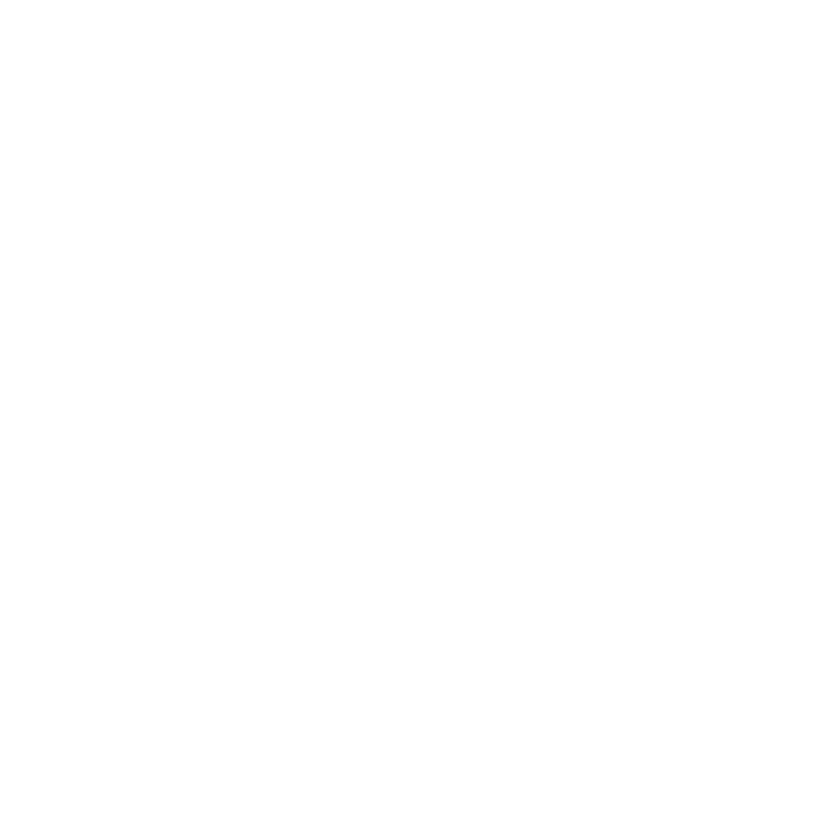

In [ ]:
# drivers
plot(df$class)
grid()

## Acceleration Data

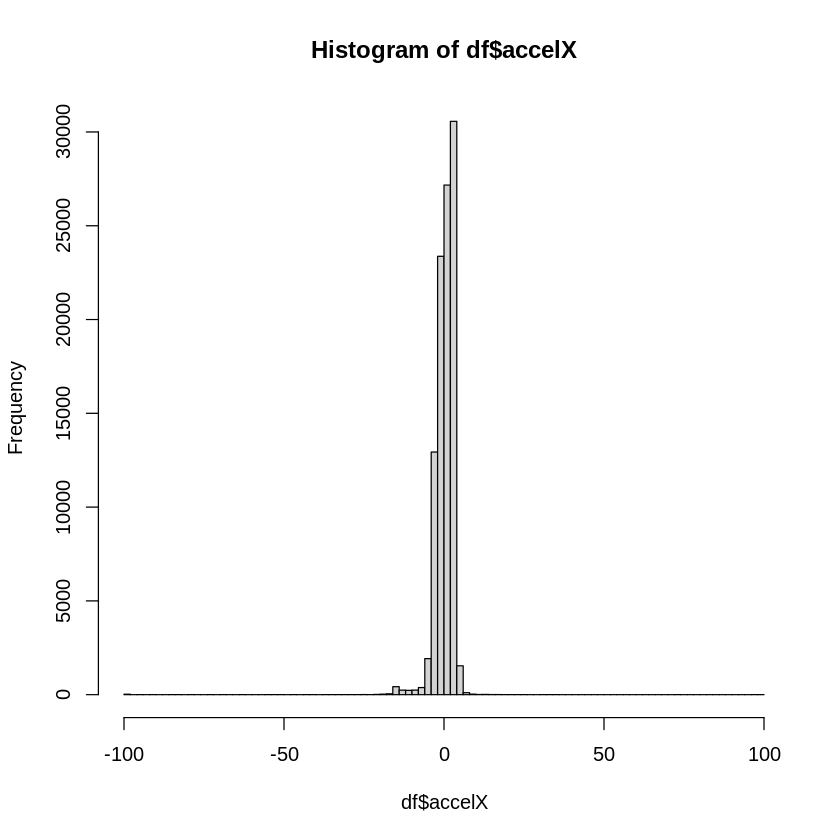

In [ ]:
hist(df$accelX,100)

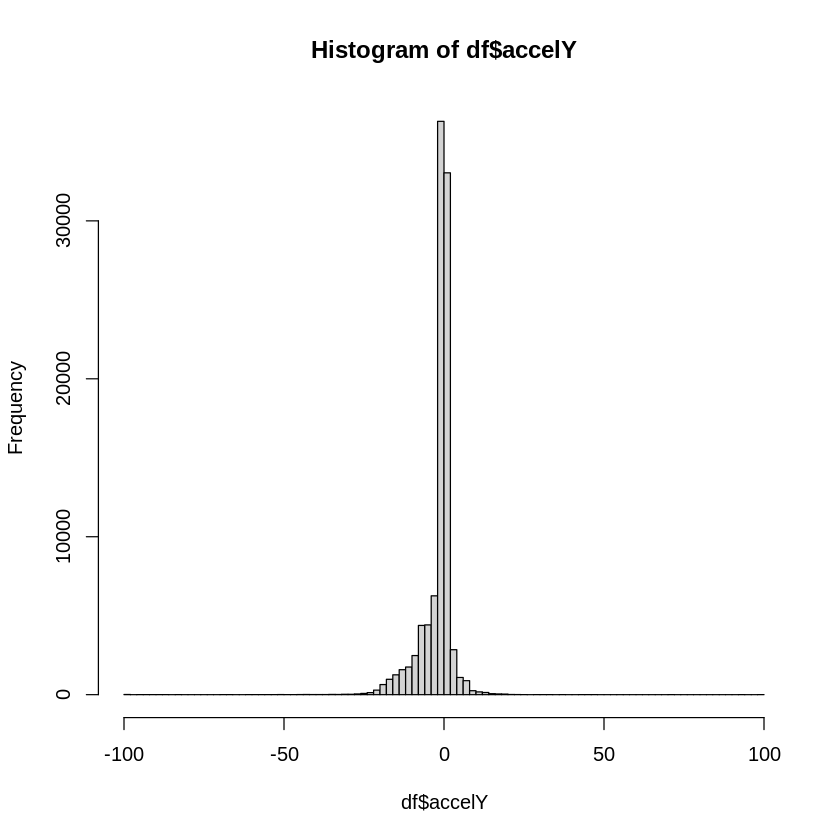

In [ ]:
hist(df$accelY,100)

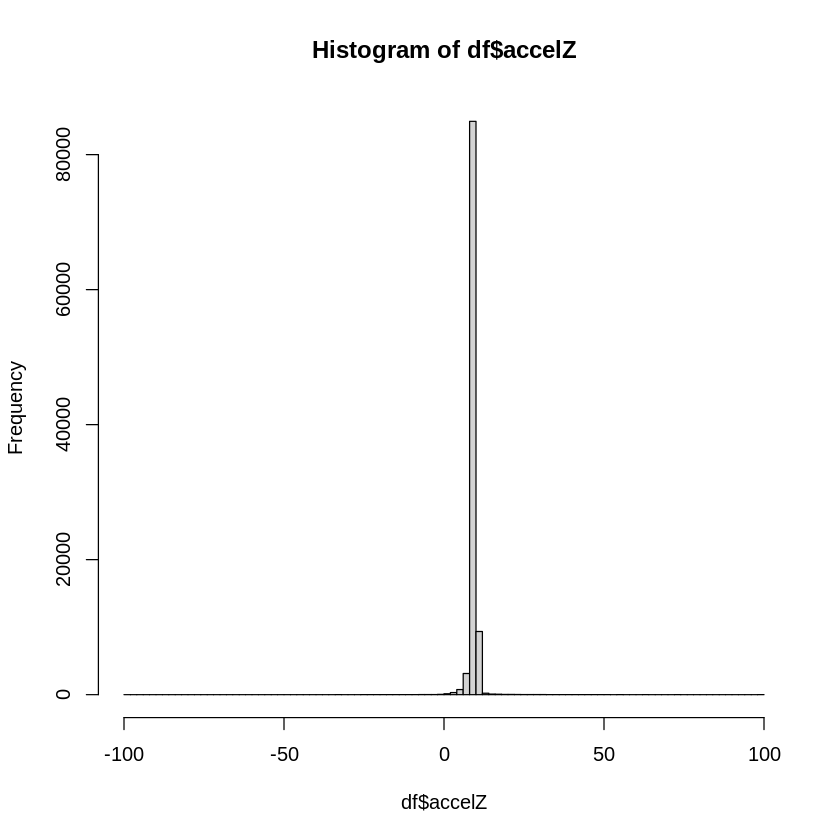

In [ ]:
hist(df$accelZ,100)

In [ ]:
# 3d plot of acceleration data
scatterplot3d(x=df$accelX, y=df$accelY, z=df$accelZ, color='#00000030',
             main='Acceleration - all drivers')

ERROR: Error in scatterplot3d(x = df$accelX, y = df$accelY, z = df$accelZ, color = "#00000030", : could not find function "scatterplot3d"


In [ ]:
# same plot split by driver
colors <- c('red', 'green', 'blue', 'magenta', 'orange', 'black', 'grey')
my_colors <- colors[as.numeric(df$class)]
scatterplot3d(x=df$accelX, y=df$accelY, z=df$accelZ, pch=16, color=my_colors,
             main='Acceleration by driver')
legend('right', inset=0.1, legend=levels(df$class), col=colors, pch=16,
       xpd=TRUE, horiz=FALSE, bty='n')

Warning message:
“NAs introduced by coercion”


ERROR: Error in scatterplot3d(x = df$accelX, y = df$accelY, z = df$accelZ, pch = 16, : could not find function "scatterplot3d"


Warning message:
“NAs introduced by coercion”


ERROR: Error in legend("right", inset = -0.05, legend = levels(df$class), col = colors, : 'legend' is of length 0


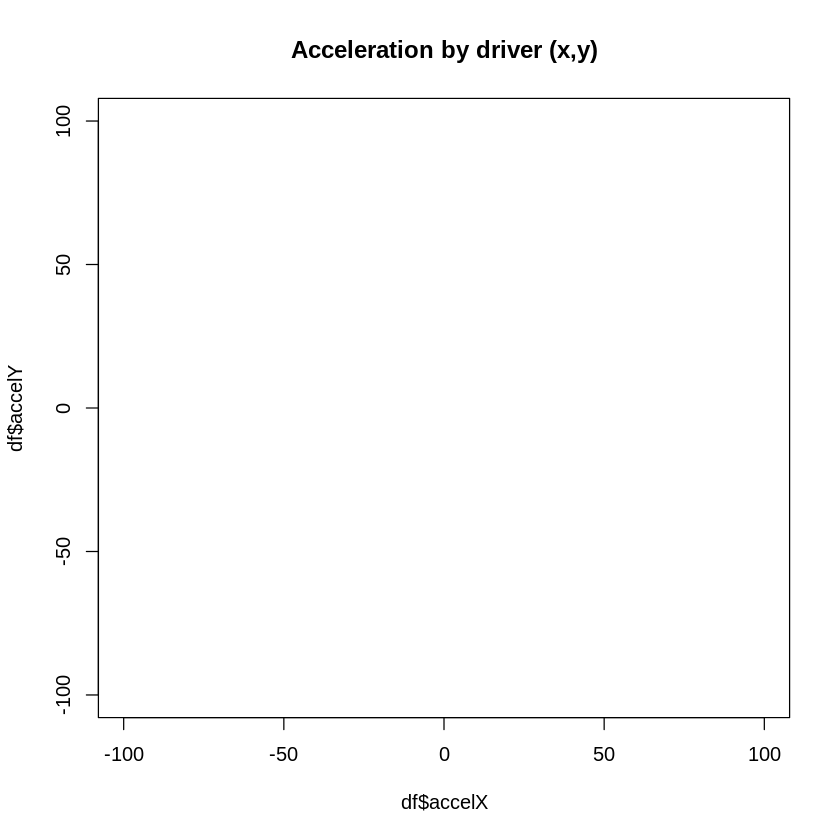

In [ ]:
# 2d plot ignoring z-component
colors <- c('red', 'green', 'blue', 'magenta', 'orange', 'black', 'grey')
my_colors <- colors[as.numeric(df$class)]
plot(x=df$accelX, y=df$accelY, pch=16, col=my_colors,
             main='Acceleration by driver (x,y)')
legend('right', inset=-0.05, legend=levels(df$class), col=colors, pch=16,
       xpd=TRUE, horiz=FALSE, bty='n')
grid()

## Gyro Data

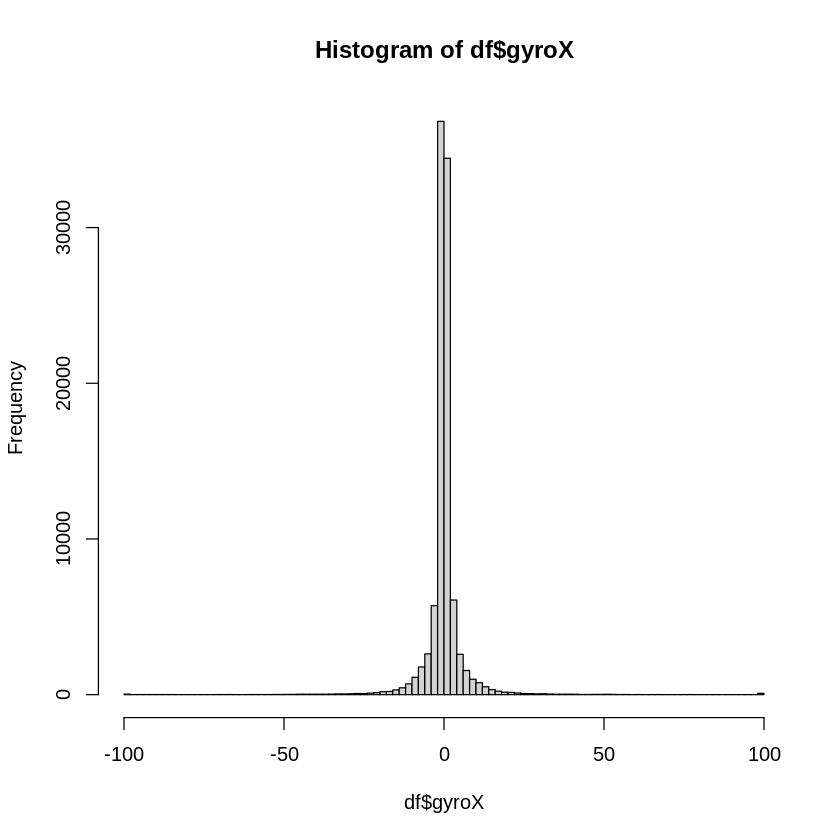

In [ ]:
hist(df$gyroX, 100)

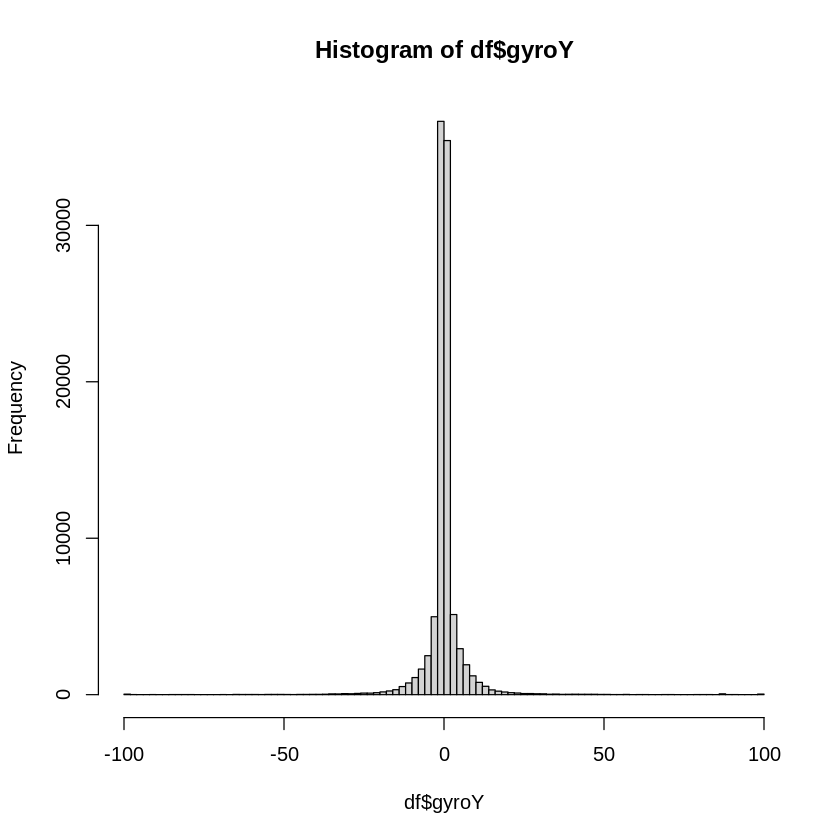

In [ ]:
hist(df$gyroY, 100)

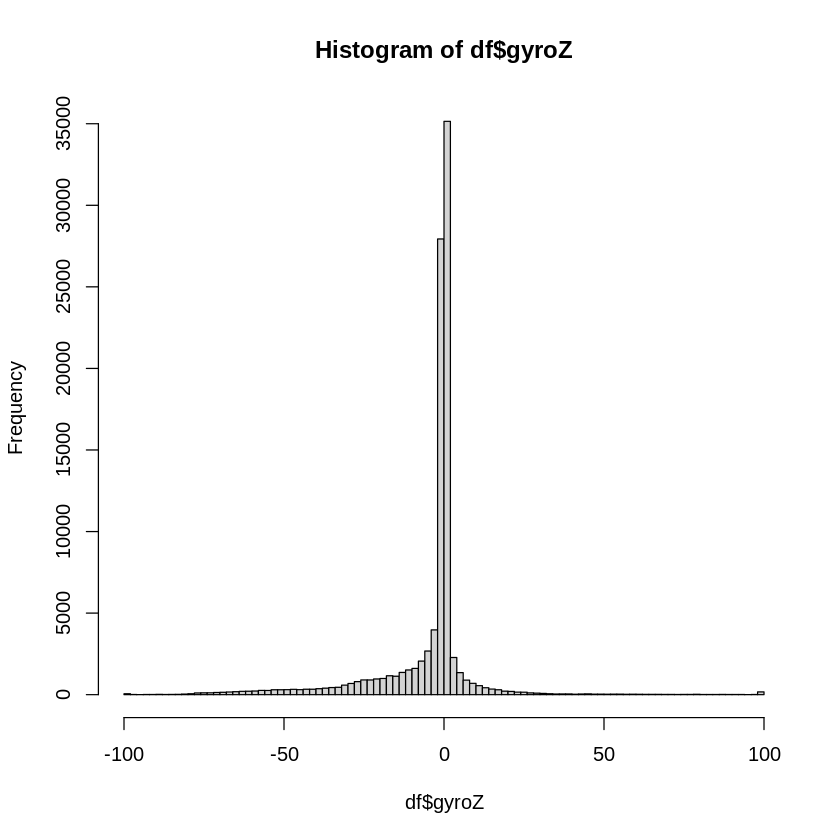

In [ ]:
hist(df$gyroZ, 100)

In [ ]:
# 3d plot of gyro data
scatterplot3d(x=df$gyroX, y=df$gyroY, z=df$gyroZ, color='#00000030',
             main='Gyro data - all drivers')

ERROR: Error in scatterplot3d(x = df$gyroX, y = df$gyroY, z = df$gyroZ, color = "#00000030", : could not find function "scatterplot3d"


In [ ]:
# same plot split by driver
colors <- c('red', 'green', 'blue', 'magenta', 'orange', 'black', 'grey')
my_colors <- colors[as.numeric(df$class)]
scatterplot3d(x=df$gyroX, y=df$gyroY, z=df$gyroZ, pch=16, color=my_colors,
             main='Gyro data by driver')
legend('right', inset=0, legend=levels(df$class), col=colors, pch=16,
       xpd=TRUE, horiz=FALSE, bty='n')

Warning message:
“NAs introduced by coercion”


ERROR: Error in scatterplot3d(x = df$gyroX, y = df$gyroY, z = df$gyroZ, pch = 16, : could not find function "scatterplot3d"
